In [59]:
import kagglehub
import os
# If you are running in a fresh environment, uncomment to install dependencies:
# !pip -q install torch torchvision matplotlib tqdm scikit-learn
import random
from PIL import Image
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torchvision import datasets, transforms
from collections import Counter
from torch.utils.data import Dataset
from torchvision.datasets import ImageFolder
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.models import vit_b_16, ViT_B_16_Weights
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
from efficientnet_pytorch import EfficientNet 
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split

print("torch:", torch.__version__)
device = "cpu"  # For fixed, reproducible results. (You may switch to "cuda" after you finish debugging.)
print("device:", device)

def set_seed(seed: int = 42):
    """Make results as reproducible as possible across runs."""
    import os, random
    import numpy as np
    import torch

    os.environ["PYTHONHASHSEED"] = str(seed)
    # If you later switch to CUDA and want maximal determinism:
    # os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Deterministic flags (safe on CPU; on GPU some ops may error if non-deterministic)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception as e:
        print("Warning: could not enable full deterministic algorithms:", e)

set_seed(42)




# Download latest version
#kagglehub.login()
path = kagglehub.competition_download('ucsc-cse-144-spring-2026-final-project')


print("Path to competition files:", path)
print(path)
print(os.listdir(path))


torch: 2.9.0+cpu
device: cpu
Path to competition files: C:\Users\ethan\.cache\kagglehub\competitions\ucsc-cse-144-spring-2026-final-project
C:\Users\ethan\.cache\kagglehub\competitions\ucsc-cse-144-spring-2026-final-project
['sample_submission.csv', 'test', 'train']


In [48]:
# Q1: Build the data pipeline
#data_dir = r"C:\Users\ethan\.cache\kagglehub\competitions\ucsc-cse-144-spring-2026-final-project"
train_dir = os.path.join(path, "train")
test_dir = os.path.join(path, "test")

print(train_dir)
print(test_dir)
batch_size = 32  # Use 128 for training
num_workers = 0  # For fully reproducible ordering across platforms

train_tf = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.RandomHorizontalFlip(),  # Data augmentation
    transforms.RandomVerticalFlip(),  # Data augmentation
    transforms.RandomRotation(10),  # Data augmentation
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # Data augmentation
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Data augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229,  0.224, 0.225])])
test_tf = transforms.Compose([
    transforms.Resize((224, 224)),  # ResNet50 expects 224x224 input
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

class CompetitionTrainDataset(Dataset):
    def __init__(self, root, transform=None):
        self.transform = transform
        self.samples = []

        for class_name in sorted(os.listdir(root), key=lambda x: int(x)):
            class_dir = os.path.join(root, class_name)
            if not os.path.isdir(class_dir):    
                continue

            label = int(class_name)

            for fname in sorted(os.listdir(class_dir)):
                if fname.endswith(".jpg"):
                    self.samples.append((os.path.join(class_dir, fname),label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label



full_train = CompetitionTrainDataset(root=train_dir, transform=train_tf)

print("Number of training images:", len(full_train))

#train_size = int(0.8 * len(full_train))
#val_size = len(full_train) - train_size

labels = [label for _, label in full_train.samples]
indices = np.arange(len(full_train))
train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

train_set = Subset(full_train, train_idx)
val_set = Subset(full_train, val_idx)

#train_set, val_set = random_split(full_train, [train_size, val_size], generator=torch.Generator().manual_seed(42))


class CompetitionTestDataset(Dataset):  
    def __init__(self, root, transform=None):   
        self.root = root
        self.transform = transform
        self.image_paths = sorted([os.path.join(root, fname) for fname in os.listdir(root) if fname.endswith('.jpg')])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        return image, os.path.basename(img_path)    

test_set = CompetitionTestDataset(root=test_dir, transform=test_tf)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=num_workers)

print("train/val/test:", len(train_set), len(val_set), len(test_set))
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch labels shape:", labels.shape)
print("Sample labels in batch:", labels[:20])

counts = Counter()

for _, label in full_train:
    counts[label] += 1

print("Number of unique classes:", len(counts))
print("Minimum samples per class:", min(counts.values()))
print("Maximum samples per class:", max(counts.values()))

C:\Users\ethan\.cache\kagglehub\competitions\ucsc-cse-144-spring-2026-final-project\train
C:\Users\ethan\.cache\kagglehub\competitions\ucsc-cse-144-spring-2026-final-project\test
Number of training images: 1079
train/val/test: 863 216 1036
Batch image shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Sample labels in batch: tensor([ 2, 87, 65, 85, 87, 32, 94, 40,  6, 90, 82, 98, 72, 62, 75, 48, 33, 49,
         5, 78])
Number of unique classes: 100
Minimum samples per class: 4
Maximum samples per class: 41


(1000, 2)
Class 0: 10
Class 1: 10
Class 2: 10
Class 3: 10
Class 4: 10
Class 5: 10
Class 6: 10
Class 7: 10
Class 8: 10
Class 9: 10
Class 10: 10
Class 11: 10
Class 12: 10
Class 13: 10
Class 14: 10
Class 15: 10
Class 16: 10
Class 17: 10
Class 18: 10
Class 19: 10
Class 20: 10
Class 21: 10
Class 22: 10
Class 23: 10
Class 24: 10
Class 25: 5
Class 26: 13
Class 27: 7
Class 28: 5
Class 29: 6
Class 30: 5
Class 31: 6
Class 32: 11
Class 33: 16
Class 34: 8
Class 35: 5
Class 36: 8
Class 37: 9
Class 38: 20
Class 39: 8
Class 40: 20
Class 41: 14
Class 42: 4
Class 43: 31
Class 44: 10
Class 45: 10
Class 46: 7
Class 47: 9
Class 48: 14
Class 49: 41
Class 50: 6
Class 51: 6
Class 52: 14
Class 53: 13
Class 54: 11
Class 55: 10
Class 56: 7
Class 57: 10
Class 58: 10
Class 59: 10
Class 60: 10
Class 61: 8
Class 62: 11
Class 63: 8
Class 64: 8
Class 65: 11
Class 66: 8
Class 67: 12
Class 68: 11
Class 69: 13
Class 70: 11
Class 71: 12
Class 72: 15
Class 73: 10
Class 74: 14
Class 75: 11
Class 76: 11
Class 77: 11
Class 7

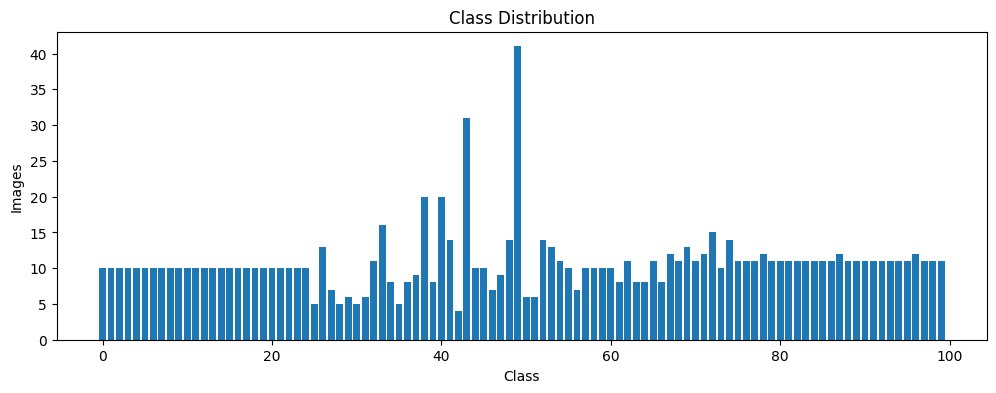

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

sample = pd.read_csv(
    os.path.join(path, "sample_submission.csv"))

print(sample.shape)

for cls in sorted(counts):
    print(f"Class {cls}: {counts[cls]}")

smallest = sorted(counts.items(), key=lambda x: x[1])[:10]
for cls, cnt in smallest:
    print(cls, cnt)

plt.figure(figsize=(12,4))
plt.bar(counts.keys(), counts.values())
plt.xlabel("Class")
plt.ylabel("Images")
plt.title("Class Distribution")
plt.show()

In [7]:
import pandas as pd

sample = pd.read_csv(
    os.path.join(path, "sample_submission.csv"))

print(sample.shape)
print(len(test_set))
print("Test image paths:", test_set.image_paths[:5])

jpgs = sorted([
    f for f in os.listdir(test_dir)
    if f.lower().endswith(".jpg")
])

print("Num jpg files:", len(jpgs))

ids = sorted(int(os.path.splitext(f)[0]) for f in jpgs)

print("Min ID:", ids[0])
print("Max ID:", ids[-1])
print("First 20 IDs:", ids[:20])
print("Last 20 IDs:", ids[-20:])


print(sample.head())
print(sample.tail())
print(ids[-20:])

(1000, 2)
1036
Test image paths: ['C:\\Users\\ethan\\.cache\\kagglehub\\competitions\\ucsc-cse-144-spring-2026-final-project\\test\\0.jpg', 'C:\\Users\\ethan\\.cache\\kagglehub\\competitions\\ucsc-cse-144-spring-2026-final-project\\test\\1.jpg', 'C:\\Users\\ethan\\.cache\\kagglehub\\competitions\\ucsc-cse-144-spring-2026-final-project\\test\\10.jpg', 'C:\\Users\\ethan\\.cache\\kagglehub\\competitions\\ucsc-cse-144-spring-2026-final-project\\test\\100.jpg', 'C:\\Users\\ethan\\.cache\\kagglehub\\competitions\\ucsc-cse-144-spring-2026-final-project\\test\\1000.jpg']
Num jpg files: 1036
Min ID: 0
Max ID: 1035
First 20 IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Last 20 IDs: [1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035]
      ID  Label
0  0.jpg     53
1  1.jpg     43
2  2.jpg     48
3  3.jpg     91
4  4.jpg     72
          ID  Label
995  995.jpg     58
996  996.jpg     17
997  997.jpg

In [54]:
# Q2: Define your CNN model
class VIT(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        self.model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
        
        for param in self.model.parameters():
            param.requires_grad = False
        
        for block in self.model.encoder.layers[-2:]:
            for param in block.parameters():
                param.requires_grad = True
        
        in_features = self.model.heads.head.in_features
        self.model.heads.head = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)



class KaggleEfficientNet(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        self.model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        
        for param in self.model.parameters():
            param.requires_grad = False

        for param in self.model.features[-4:].parameters():
            param.requires_grad = True
        
        in_features = self.model.classifier[1].in_features
        self.model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.model(x)



class KaggleResNet(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        self.model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        
        for param in self.model.parameters():
            param.requires_grad = False
        
        in_features = self.model.fc.in_features
        self.model.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # Pass input through features, then classifier
        return self.model(x)

model = VIT(num_classes=100).to(device)
print(model)

# Parameter count
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total params:", num_params)


VIT(
  (model): VisionTransformer(
    (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (encoder): Encoder(
      (dropout): Dropout(p=0.0, inplace=False)
      (layers): Sequential(
        (encoder_layer_0): EncoderBlock(
          (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (self_attention): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (dropout): Dropout(p=0.0, inplace=False)
          (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): MLPBlock(
            (0): Linear(in_features=768, out_features=3072, bias=True)
            (1): GELU(approximate='none')
            (2): Dropout(p=0.0, inplace=False)
            (3): Linear(in_features=3072, out_features=768, bias=True)
            (4): Dropout(p=0.0, inplace=False)
          )
        )
        (encoder_layer_1): EncoderBlock(
          (ln_1): LayerNorm((

In [ ]:
# Q3.1: Training function
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-5)

scheduler1 = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

def train_one_epoch(model, loader):
    """Train for one epoch and return (avg_loss, accuracy)."""
    # ========== YOUR CODE STARTS HERE ==========
    # TODO:
    # - Set model to training mode
    # - Loop through batches in the loader
    # - For each batch: 
    #   * Zero gradients
    #   * Forward pass
    #   * Compute loss
    #   * Backward pass
    #   * Optimizer step
    # - Track total loss and accuracy (IMPORTANT: get predicted labels and compare with targets)
    # - Return average loss and accuracy
    model.train()
    total_loss = 0.0
    correct  = 0
    total = 0
    for images, targets in loader:
        images, targets = images.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * images.size(0) 
        _, predicted = torch.max(outputs, dim=1)
        correct += (predicted == targets).sum().item()
        total += targets.size(0)
    avg_loss = total_loss / total
    accuracy = correct / total    
    return avg_loss, accuracy
    # ========== YOUR CODE ENDS HERE ============

In [56]:
# Q3.2: Validation function
@torch.no_grad()
def evaluate(model, loader):
    """Evaluate model and return (avg_loss, accuracy)."""
    # ========== YOUR CODE STARTS HERE ==========
    # TODO:
    # - Set model to evaluation mode
    # - Loop through batches without computing gradients
    # - Compute loss and accuracy
    # - Return average loss and accuracy
    model.eval()
    total_loss = 0.0
    correct  = 0
    total = 0
    for images, targets in loader:
        images, targets = images.to(device), targets.to(device)
        outputs = model(images)
        loss = criterion(outputs, targets)
        
        total_loss += loss.item() * images.size(0) 
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == targets).sum().item()
        total += targets.size(0)
    avg_loss = total_loss / total
    accuracy = correct / total
    
    return avg_loss, accuracy
    # ========== YOUR CODE ENDS HERE ============

In [41]:
#Training loop with checkpointing
epochs = 15
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
best_epoch = -1
ckpt_path = "./checkpoints/best_kaggle_cnn.pt"
os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

patience = 6
epochs_without_improvement = 0

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = evaluate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        epochs_without_improvement = 0
        torch.save({"model_state_dict": model.state_dict(), "optimizer_state_dict": optimizer.state_dict(), "epoch": epoch + 1, "val_acc": val_acc}, ckpt_path)
    else: 
        epochs_without_improvement += 1

    scheduler.step(val_acc)

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"LR: {current_lr:.6f} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "    
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if epochs_without_improvement >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

# ========== YOUR CODE ENDS HERE ============

print("Best val acc:", best_val_acc, "at epoch", best_epoch)
print("Saved to:", ckpt_path)

Epoch [1/15] | LR: 0.000100 | Train Loss: 4.4044 | Train Acc: 0.0973 | Val Loss: 4.2247 | Val Acc: 0.1435
Epoch [2/15] | LR: 0.000100 | Train Loss: 4.1012 | Train Acc: 0.1472 | Val Loss: 3.9229 | Val Acc: 0.1944
Epoch [3/15] | LR: 0.000100 | Train Loss: 3.8075 | Train Acc: 0.2097 | Val Loss: 3.6910 | Val Acc: 0.2222
Epoch [4/15] | LR: 0.000100 | Train Loss: 3.5744 | Train Acc: 0.2526 | Val Loss: 3.4265 | Val Acc: 0.2824
Epoch [5/15] | LR: 0.000100 | Train Loss: 3.2951 | Train Acc: 0.3187 | Val Loss: 3.2232 | Val Acc: 0.2870
Epoch [6/15] | LR: 0.000100 | Train Loss: 3.0527 | Train Acc: 0.3778 | Val Loss: 3.0009 | Val Acc: 0.4074
Epoch [7/15] | LR: 0.000100 | Train Loss: 2.8243 | Train Acc: 0.4380 | Val Loss: 2.8288 | Val Acc: 0.4167
Epoch [8/15] | LR: 0.000100 | Train Loss: 2.6185 | Train Acc: 0.4890 | Val Loss: 2.6851 | Val Acc: 0.4352
Epoch [9/15] | LR: 0.000100 | Train Loss: 2.3962 | Train Acc: 0.5655 | Val Loss: 2.5678 | Val Acc: 0.5000
Epoch [10/15] | LR: 0.000100 | Train Loss: 2.2

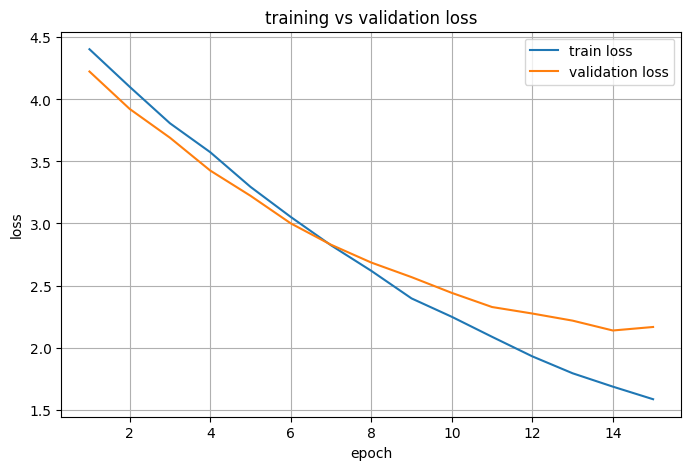

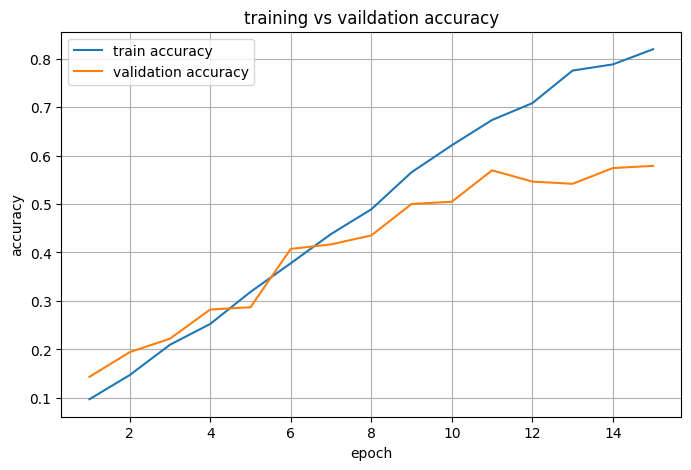

In [ ]:
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_loss"], label="train loss")
plt.plot(epochs_range, history["val_loss"], label="validation loss")

plt.title("training vs validation loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_acc"], label="train accuracy")
plt.plot(epochs_range, history["val_acc"], label="validation accuracy")
plt.title("training vs vaildation accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
checkpoint = torch.load(ckpt_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

print(checkpoint.keys())
print(checkpoint["epoch"])
print(type(model))

model.to(device)
model.eval()

predictions = []
filenames = []

with torch.no_grad():
    for images, paths in tqdm(test_loader, desc="Predicting on test set"):
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, dim=1)
        predictions.extend(predicted.cpu().numpy())
        filenames.extend(paths)
print("Predictions generated:", len(predictions))

sample = pd.read_csv(os.path.join(path, "sample_submission.csv"))

prediction_dict = {fname: pred for fname, pred in zip(filenames, predictions)}
sample.columns = sample.columns.str.strip()
#sample["label"] = sample["ID"].apply(lambda x: prediction_dict.get(f"{x}.jpg", 0))
sample[label] = sample["ID"].map(prediction_dict)
print("Missing predictions:", sample["Label"].isnull().sum())

submission_path = "submission.csv"
sample.to_csv(submission_path, index=False)
print("Submission saved to:", submission_path) 
print(sample.head())

#print("loaded checkpoint from epoch:", checkpoint["epoch"])

#print(f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

dict_keys(['model_state_dict', 'optimizer_state_dict', 'epoch', 'val_acc'])
15
<class '__main__.VIT'>


Predicting on test set:   0%|          | 0/33 [00:00<?, ?it/s]

KeyboardInterrupt: 